Data Loading and Preprocessing


We will use the Hugging Face IMDB movie review dataset for sentiment analysis with a bi-directional LSTM model.


In [1]:
!uv pip install datasets matplotlib


Using Python 3.12.13 environment at: /usr
Checked 2 packages in 202ms


In [2]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from datasets import load_dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset


In [16]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_VOCAB = 20000
BATCH_SIZE = 64
EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.3
EPOCHS = 4

print(f"Device: {DEVICE}")


Device: cuda


In [4]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    return re.findall(r"\b\w+\b", text)


def load_imdb():
    print("Downloading/Loading Hugging Face IMDB dataset...")
    dataset = load_dataset("imdb")
    train_texts = dataset["train"]["text"]
    train_labels = dataset["train"]["label"]
    test_texts = dataset["test"]["text"]
    test_labels = dataset["test"]["label"]
    return train_texts, train_labels, test_texts, test_labels


In [5]:
train_texts, train_labels, test_texts, test_labels = load_imdb()
print(f"Training samples: {len(train_texts)}")
print(f"Test samples: {len(test_texts)}")


Downloading/Loading Hugging Face IMDB dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Training samples: 25000
Test samples: 25000


In [6]:
def build_vocab(texts, max_vocab):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    word2idx = {"<PAD>": 0, "<UNK>": 1}
    for word, _ in counter.most_common(max_vocab - 2):
        word2idx[word] = len(word2idx)
    return word2idx


def encode(text, word2idx):
    tokens = tokenize(text)
    return [word2idx.get(token, word2idx["<UNK>"]) for token in tokens]


In [7]:
word2idx = build_vocab(train_texts, MAX_VOCAB)
vocab_size = len(word2idx)
print(f"Vocabulary size: {vocab_size}")


Vocabulary size: 20000


We use token indexing, dynamic padding, and packed sequences so the BiLSTM processes only the real review lengths inside each batch.


In [8]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, word2idx):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = encode(self.texts[idx], self.word2idx)
        if not encoded:
            encoded = [self.word2idx["<UNK>"]]
        return encoded, self.labels[idx]


def collate_fn(batch):
    sequences = [torch.tensor(item[0], dtype=torch.long) for item in batch]
    lengths = torch.tensor([len(sequence) for sequence in sequences], dtype=torch.long)
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True, padding_value=0)
    return padded, lengths, labels


In [9]:
train_ds = IMDBDataset(train_texts, train_labels, word2idx)
test_ds = IMDBDataset(test_texts, test_labels, word2idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)


Model Training


In [10]:
class SentimentBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, num_classes=2, dropout=DROPOUT):
        super().__init__()
        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        final_hidden = torch.cat((forward_hidden, backward_hidden), dim=1)
        return self.fc(self.dropout(final_hidden))


Training


In [11]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, lengths, y in loader:
        x, lengths, y = x.to(DEVICE), lengths.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x, lengths)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for x, lengths, y in loader:
        x, lengths, y = x.to(DEVICE), lengths.to(DEVICE), y.to(DEVICE)
        logits = model(x, lengths)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


In [17]:
model = SentimentBiLSTM(vocab_size).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    print(
        f"Epoch {epoch}/{EPOCHS}  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
        f"test_loss={test_loss:.4f}  test_acc={test_acc:.4f}"
    )


Epoch 1/4  train_loss=0.5987  train_acc=0.6686  test_loss=0.5531  test_acc=0.6992
Epoch 2/4  train_loss=0.3890  train_acc=0.8262  test_loss=0.3591  test_acc=0.8426
Epoch 3/4  train_loss=0.2498  train_acc=0.9030  test_loss=0.3043  test_acc=0.8688
Epoch 4/4  train_loss=0.1845  train_acc=0.9325  test_loss=0.3068  test_acc=0.8760


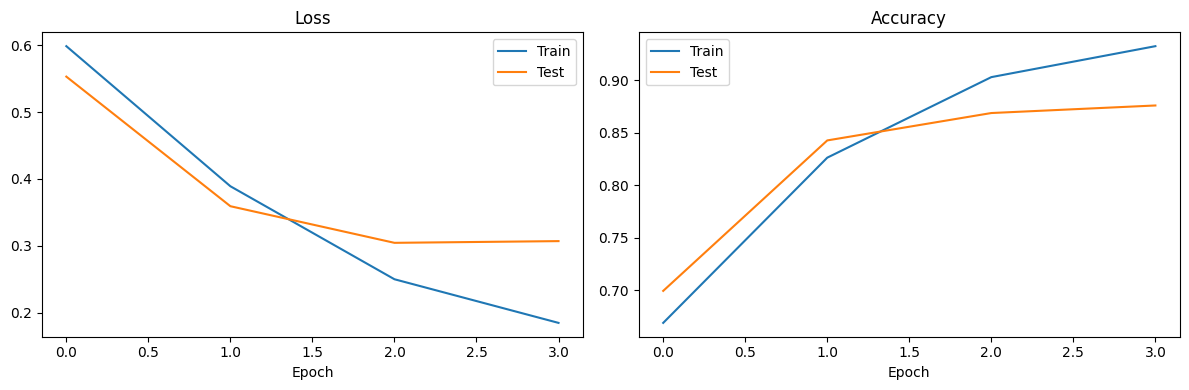

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["test_loss"], label="Test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["test_acc"], label="Test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


In [19]:
@torch.no_grad()
def predict_text(model, text, word2idx):
    model.eval()
    ids = encode(text, word2idx)
    if not ids:
        ids = [word2idx["<UNK>"]]
    x = torch.tensor([ids], dtype=torch.long).to(DEVICE)
    lengths = torch.tensor([len(ids)], dtype=torch.long).to(DEVICE)
    logits = model(x, lengths)
    return logits.argmax(dim=1).item()


label_map = {0: "negative", 1: "positive"}
samples = test_texts[:5]
sample_labels = test_labels[:5]
predictions = [predict_text(model, text, word2idx) for text in samples]

for i, (text, true_label, pred_label) in enumerate(zip(samples, sample_labels, predictions), start=1):
    print(f"Sample {i}")
    print(text[:200] + "...")
    print(f"True: {label_map[true_label]} | Predicted: {label_map[pred_label]}")
    print()


Sample 1
I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Bab...
True: negative | Predicted: negative

Sample 2
Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles with the 40 shell ...
True: negative | Predicted: negative

Sample 3
its a totally average film with a few semi-alright action sequences that make the plot seem a little better and remind the viewer of the classic van dam films. parts of the plot don't make sense and s...
True: negative | Predicted: negative

Sample 4
STAR RATING: ***** Saturday Night **** Friday Night *** Friday Morning ** Sunday Night * Monday Morning <br /><br />Former New Orleans homicide cop Jack Robideaux (Jean Claude Van Damme) is re-assigne...
True: negative | Predicted: negati

Bi-directional LSTM captures context from both past and future tokens in each review, so it usually performs better than a plain RNN on IMDB sentiment classification.
